# Random Forestモデルの構築

In [8]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree

import graphviz
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)

In [5]:
x_train = pd.read_csv('../data/treated-data/df_x_train.csv')
y_train = pd.read_csv('../data/treated-data/df_y_train.csv')
x_test = pd.read_csv('../data/treated-data/df_x_test.csv')
y_test = pd.read_csv('../data/treated-data/df_y_test.csv')

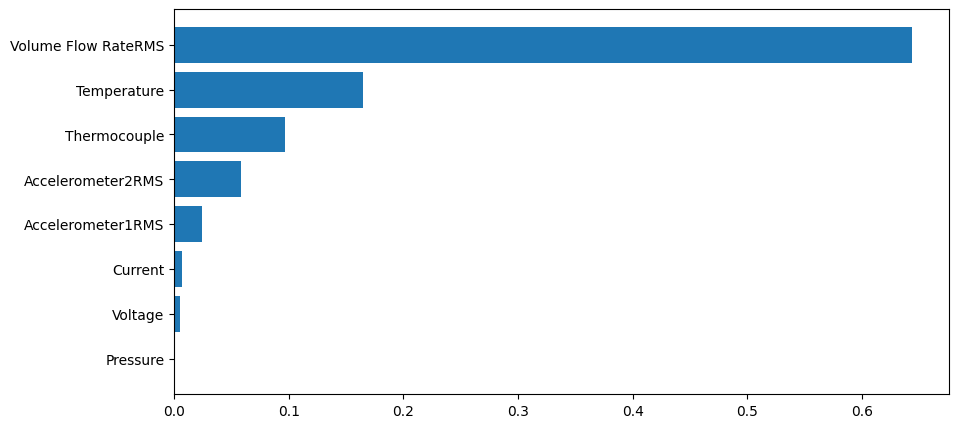

In [14]:
SKAB_clf2 = RandomForestClassifier(random_state=0, max_depth=3, n_estimators=150)
SKAB_clf2 = SKAB_clf2.fit(x_train, y_train)

features = x_train.columns
importances = SKAB_clf2.feature_importances_
indices = np.argsort(importances)

#重要度を降順に並び替え横棒プロットする
plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.show()